# Notas preliminares

Dataset base: resultados de partidos WTA desde 2007 hasta ahora
Entrenar modelo partido a partido (quien gana y con qué porcentaje)
Validar simulando el último grand slam y los dos torneos previos de tierra por ejemplo?
Simular el próximo Roland Garros

Tengo datos desde 2007 hasta 2026 (actualizados diariamente)
Entrenar con todos los datos desde 2007
Ponderar más los últimos 3-5 años



In [ ]:
# Ejemplo simple de peso temporal. Por si hay que aplicar a alguna feature
import numpy as np

años_atras = 2024 - año_partido
peso = np.exp(-0.1 * años_atras)  # decae exponencialmente

Para cada partido del cuadro → predice probabilidad A gana B
→ avanza el ganador (o haz 10.000 sorteos ponderados)
→ cuenta cuántas veces gana cada jugadora el torneo

La simulación de Monte Carlo suena intimidante pero con el modelo ya entrenado es sorprendentemente sencilla — básicamente un bucle que repite el torneo miles de veces usando las probabilidades que predice tu modelo en cada partido.

Montecarlo
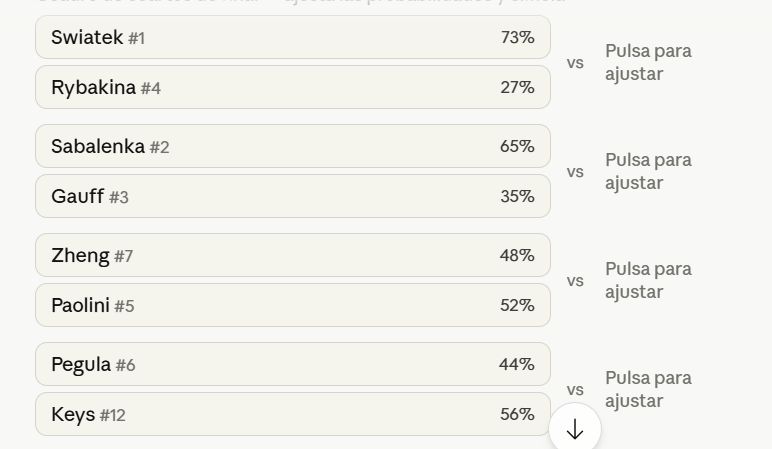

Simulación del cuadro, llamo al predictor en cada partido, cargo la predicción obtenida

Clasificador  →  predict_proba()  →  probabilidad  →  dado cargado  →  ganadora
  (entrena)        (infiere)          [0.73, 0.27]     random()         Swiatek

┌─────────────────────────────────────────┐
│           SIMULACIÓN MONTE CARLO        │  ← repite 10.000 veces
│                                         │
│   Cuartos → Semis → Final               │
│   para cada partido llama a...          │
│                                         │
│   ┌─────────────────────────────────┐   │
│   │         TU MODELO ML            │   │  ← entrenado con datos históricos
│   │  input: jugadora A vs B         │   │
│   │  output: probabilidad 0..1      │   │
│   └─────────────────────────────────┘   │
│                                         │
└─────────────────────────────────────────┘
         ↓ resultado final
   {"Swiatek": 38%, "Sabalenka": 22%, ...}

In [ ]:
# Código de base para Monte Carlo
def simular_partido(prob_a):
  # lanzamos un dado cargado
  return random.random() < prob_a

def simular_torneo(cuadro, modelo):
  jugadoras = cuadro.copy()
  while len(jugadoras) > 1:
    siguiente_ronda = []
    for i in range(0, len(jugadoras), 2):
      a, b = jugadoras[i], jugadoras[i+1]
      prob_a = modelo.predict_proba(a, b)
      ganadora = a if simular_partido(prob_a) else b
      siguiente_ronda.append(ganadora)
    jugadoras = siguiente_ronda
  return jugadoras[0]

Fase 1 — entrenamiento: aprende de 44.000 partidos históricos. Esto pasa una vez.
Fase 2 — inferencia: dado un cuadro real, preguntas al modelo miles de veces. Esto pasa cuando quieres predecir.

Cuotas de apuestas: (ej: 1.33 vs 3.00)
Es un predictor genial pero claro, no voy a tenerlo antes de los partidos en el simulador de Roland Garros.
Solo existen cuando el partido ya está anunciado y las casas las publican
Conversor de cuota a porcentaje: 1/cuota. 1/1.33 = 75%
Creo que lo quitaré del entrenamiento y de alguna forma puedo usarlo como medida de cuanto de bueno es mi predictor vs casas de apuestas

Valoraré si incluir estadísticas. Por el momento buscar cómo inferir datos adicionales de los datos que hay.
Estado de forma:
% partidos ganados en los últimos 2-3 meses?
% sets ganados en el último 2-3 meses?

Histórico:
Head to head histórico
Win rate de cada jugadora en esa superficie concreta
Win rate en esa ronda concreta (hay jugadoras que rinden mejor en finales)
Ratio Puntos Totales Ganados/Perdidos 
% Juegos Ganados al Saque: Mide la solidez del servicio. Jugadores top suelen estar por encima del 85-90%.
% Puntos de Quiebre (Break Points): Convertir oportunidades de quiebre y salvar las propias es crucial para ganar partidos ajustados.
% Primer Servicio
% Puntos con 2do Servicio
Errores No Forzados vs. Golpes Ganadores:  